# **Analyse et Ingénierie des données de la chlordécone aux Antilles françaises**

# Notebook 2 – Nettoyage et cleaning des données

## Objectifs de ce notebook
- Identifier et visualiser les valeurs manquantes
- Détecter les incohérences et anomalies
- Corriger les types de données (dates, numériques)
- Appliquer des stratégies d'imputation
- Exporter un DataFrame nettoyé reproductible

## 1. Import & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Chemins relatifs pour la reproductibilité
NOTEBOOK_DIR = os.getcwd()
FIG_DIR  = os.path.join(NOTEBOOK_DIR, 'fig', '2-nettoyage_cleaning')
DATA_OUT = NOTEBOOK_DIR  # Le CSV nettoyé sera sauvegardé dans le même dossier
os.makedirs(FIG_DIR, exist_ok=True)

# Chargement du fichier CSV (séparateur point-virgule, format français)
df_raw = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'BaseCLD2026.csv'),
    sep=';'
)
df = df_raw.copy()  # On travaille sur une copie pour préserver les données brutes

# Conversion numérique des colonnes lues comme str
cols_numeriques = ['Taux_Chlordecone', 'Taux_5b_hydro', 'histoBanane_Histo_ban',
                   'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean',
                   'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean', 'X', 'Y']
for col in cols_numeriques:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')  # aussi sur df_raw pour le bilan

print(f'Données chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Données chargées : 31,126 lignes × 22 colonnes


## 2. Analyse des valeurs manquantes

In [2]:
# Tableau des valeurs manquantes
missing = pd.DataFrame({
    'Nb manquant': df.isnull().sum(), # Nombre de valeurs manquantes par colonne
    '% manquant': (df.isnull().sum() / len(df) * 100).round(2) # Pourcentage de valeurs manquantes par colonne
}).query('`Nb manquant` > 0').sort_values('% manquant', ascending=False) # Tri de manière décroissant et filtre pour ne garder que les colonnes avec des valeurs manquantes

print('Colonnes avec valeurs manquantes :')
missing

Colonnes avec valeurs manquantes :


,Nb manquant,% manquant
Taux_5b_hydro,29066,93.38
histoBanane_Histo_ban,17983,57.77
type_sol,2609,8.38
COMMU_LAB,298,0.96
Sol_simple,74,0.24
mnt_tpi_mean,28,0.09
mnt_tri_mean,28,0.09
mnt_rugosite_mean,28,0.09
mnt_ombrage_mean,28,0.09
mnt_exposition_mean,28,0.09


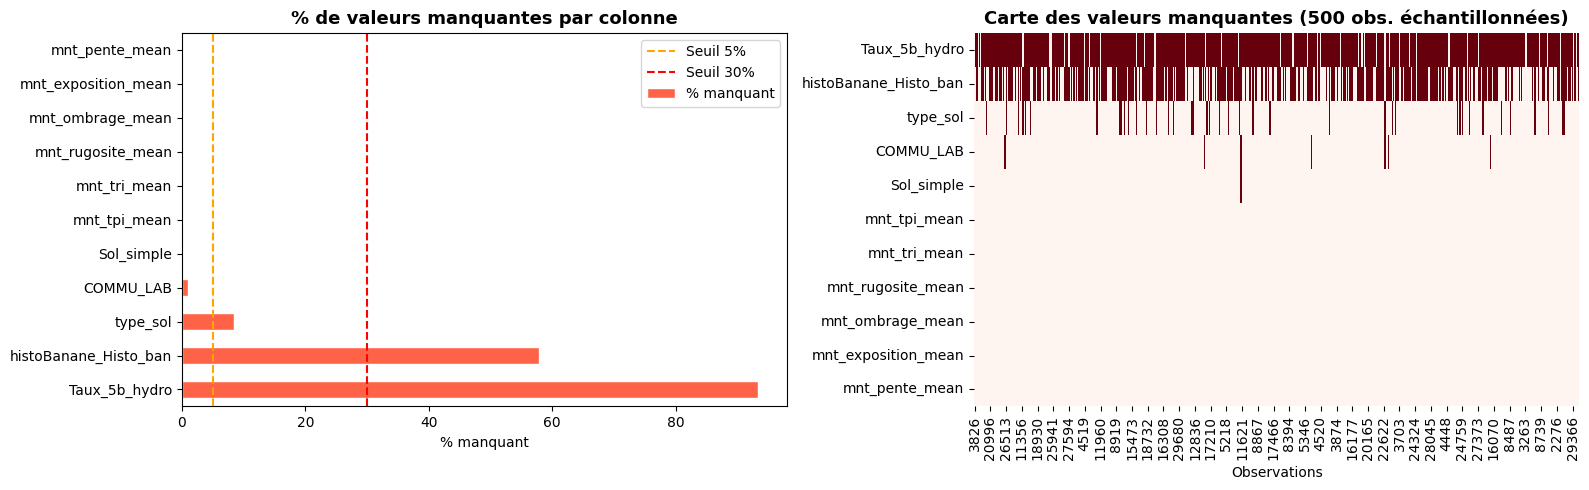

Figure sauvegardée.


In [3]:
# Visualisation des valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique en barres du % de valeurs manquantes
missing['% manquant'].plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('% de valeurs manquantes par colonne', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% manquant')
axes[0].axvline(x=5,  color='orange', linestyle='--', label='Seuil 5%')
axes[0].axvline(x=30, color='red',    linestyle='--', label='Seuil 30%')
axes[0].legend()

# Heatmap des valeurs manquantes (échantillon de 500 obs.)
sample_miss = df[missing.index].isnull().sample(min(500, len(df)), random_state=42)
sns.heatmap(sample_miss.T, cbar=False, ax=axes[1], cmap='Reds', yticklabels=True)
axes[1].set_title('Carte des valeurs manquantes (500 obs. échantillonnées)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Observations')

plt.tight_layout()
# Chemin relatif + nom de fichier corrigé (était 'fig_taux_par_sol' par erreur)
plt.savefig(os.path.join(FIG_DIR, 'fig_missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

## 3. Correction des types de données

In [4]:
# 3.1 Colonnes de dates 
date_cols = ['Date_prelevement', 'Date_enregistrement', 'Date_analyse'] # Liste des colonnes qui devraient être des dates

for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce') # Conversion en datetime, avec dayfirst=True pour le format jour/mois/année et errors='coerce' pour convertir les valeurs invalides en NaT
    print(f'  {col} -> datetime | Erreurs de conversion : {df[col].isnull().sum()}') # Affiche le nombre d'erreurs de conversion (valeurs non converties en dates)

print()
df[date_cols].dtypes

  Date_prelevement -> datetime | Erreurs de conversion : 0
  Date_enregistrement -> datetime | Erreurs de conversion : 0
  Date_analyse -> datetime | Erreurs de conversion : 0



Date_prelevement       datetime64[us]
Date_enregistrement    datetime64[us]
Date_analyse           datetime64[us]
dtype: object

Ici aucune erreur de conversion au format "Date".

In [5]:
# 3.2 Taux_5b_hydro
print('Valeurs brutes de Taux_5b_hydro (avant nettoyage) :')
print(df['Taux_5b_hydro'].value_counts().head(10)) # Affiche les 10 valeurs les plus fréquentes dans la colonne Taux_5b_hydro pour identifier les formats problématiques

df['Taux_5b_hydro'] = (
    df['Taux_5b_hydro'] 
    .astype(str) # Convertit en string pour pouvoir appliquer les transformations suivantes
    .str.replace(',', '.', regex=False)  # On remplace les virgules par des points pour les décimales
    .str.strip() # Supprime les espaces éventuels
    .replace('inf', np.nan) # Remplace les valeurs 'inf' par NaN pour éviter les problèmes de conversion en float
    .replace('nan', np.nan) # Remplace les valeurs 'nan' (en string) par NaN pour éviter les problèmes de conversion en float
)
df['Taux_5b_hydro'] = pd.to_numeric(df['Taux_5b_hydro'], errors='coerce') # Convertit en float, avec errors='coerce' pour convertir les valeurs non convertibles en NaN

print(f'\n Taux_5b_hydro converti en float | Valeurs manquantes : {df["Taux_5b_hydro"].isnull().sum()}') # Affiche le nombre de valeurs manquantes après conversion
df['Taux_5b_hydro'].describe() # Affiche les statistiques descriptives de la colonne "Taux_5b_hydro" après transfo.

Valeurs brutes de Taux_5b_hydro (avant nettoyage) :
Taux_5b_hydro
0.0      1336
inf       586
999.0     138
Name: count, dtype: int64

 Taux_5b_hydro converti en float | Valeurs manquantes : 29652


count    1474.000000
mean       93.529172
std       291.110684
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       999.000000
Name: Taux_5b_hydro, dtype: float64

## 4. Détection des incohérences et anomalies

 Valeurs aberrantes : 4,248 observations
 Seuil = 1.633 mg/kg
 Max observé = 17.35 mg/kg


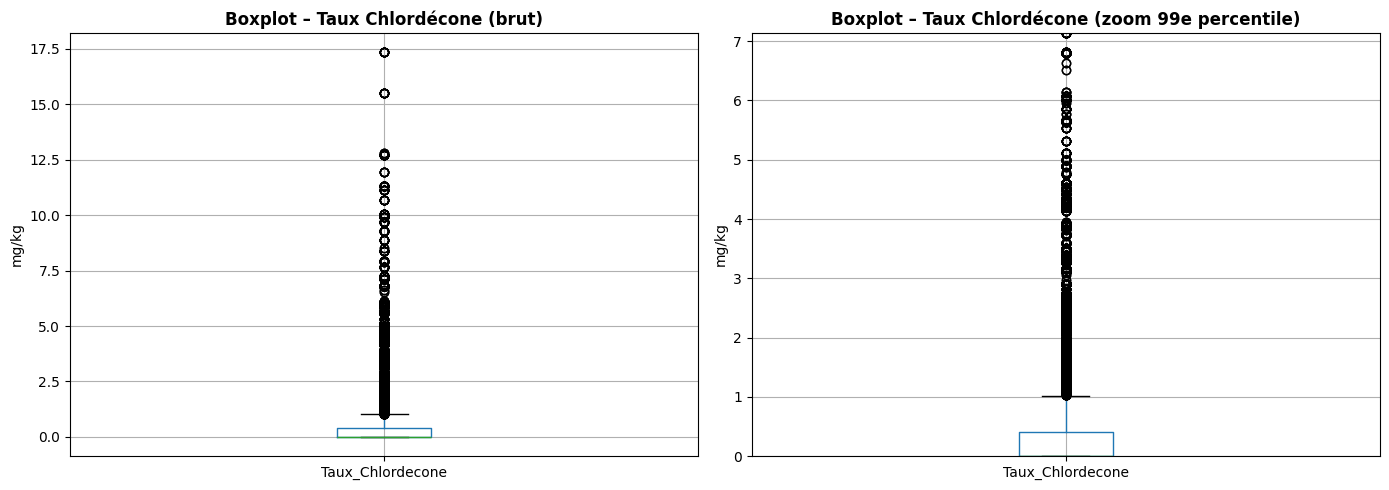

Figure sauvegardée.


In [6]:
# 4.1 Valeurs aberrantes pour le taux de chlordécone (méthode IQR)
Q1 = df['Taux_Chlordecone'].quantile(0.25)
Q3 = df['Taux_Chlordecone'].quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 3 * IQR  # Seuil à 3×IQR (moins strict que 1.5×IQR pour ce type de données)

outliers = df[df['Taux_Chlordecone'] > borne_sup]
print(f' Valeurs aberrantes : {len(outliers):,} observations')
print(f' Seuil = {borne_sup:.3f} mg/kg')
print(f' Max observé = {df["Taux_Chlordecone"].max()} mg/kg')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Taux_Chlordecone', ax=axes[0])
axes[0].set_title('Boxplot – Taux Chlordécone (brut)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('mg/kg')

df.boxplot(column='Taux_Chlordecone', ax=axes[1])
axes[1].set_ylim(0, df['Taux_Chlordecone'].quantile(0.99))  # Zoom sur le 99e percentile
axes[1].set_title('Boxplot – Taux Chlordécone (zoom 99e percentile)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('mg/kg')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_outliers.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

In [7]:
# 4.2 Vérification de la cohérence temporelle
# La date d'analyse doit être >= date d'enregistrement >= date de prélèvement
incoherence_1 = df[df['Date_enregistrement'] < df['Date_prelevement']] # Sélectionne les observations où la date d'enregistrement est antérieure à la date de prélèvement (anormale)
incoherence_2 = df[df['Date_analyse'] < df['Date_enregistrement']] # Sélectionne les observations où la date d'analyse est antérieure à la date d'enregistrement

# Affichage des cas d'incohérence temporelle
print(f'Date enregistrement < Date prélèvement : {len(incoherence_1)} cas')
print(f'Date analyse < Date enregistrement    : {len(incoherence_2)} cas')

# Délai moyen traitement
df['delai_prelevement_analyse'] = (df['Date_analyse'] - df['Date_prelevement']).dt.days # Calcule le délai en jours entre la date de prélèvement et la date d'analyse
print(f'\n Délai moyen prélèvement → analyse : {df["delai_prelevement_analyse"].mean():.0f} jours') # Affiche le délai moyen en jours entre le prélèvement et l'analyse

Date enregistrement < Date prélèvement : 1453 cas
Date analyse < Date enregistrement    : 1184 cas

 Délai moyen prélèvement → analyse : 253165 jours


In [8]:
# 4.3 Modalités incohérentes dans Sol_simple
print('Modalités de Sol_simple avant nettoyage :')
print(df['Sol_simple'].value_counts(dropna=False)) # Affiche les modalités de la colonne "Sol_simple" avec le nombre d'occurrences, en incluant les valeurs manquantes (NaN)

# Remplacement des modalités 'No data' et 'Urban area' par NaN
df['Sol_simple'] = df['Sol_simple'].replace({'No data': np.nan, 'Urban area': np.nan}) # Remplacement des modalités qui faussent l'analyse du sol
print('\n Après nettoyage :')
print(df['Sol_simple'].value_counts(dropna=False))

Modalités de Sol_simple avant nettoyage :
Sol_simple
Andosol                10953
Vertisol                6921
Ferralsol               5182
Nitisol                 3063
No data                 2617
Alluvium, Colluvium     1604
Urban area               712
NaN                       74
Name: count, dtype: int64

 Après nettoyage :
Sol_simple
Andosol                10953
Vertisol                6921
Ferralsol               5182
NaN                     3403
Nitisol                 3063
Alluvium, Colluvium     1604
Name: count, dtype: int64


## 5. Stratégies d'imputation des valeurs manquantes

In [9]:
# 5.1 COMMU_LAB : imputation par coordonnées proches
# On conserve NaN (la commune peut être retrouvée via ses coordonnées X et Y)
print(f'COMMU_LAB manquant : {df["COMMU_LAB"].isnull().sum()} obs. → conservés (info disponible via X/Y)') # Affiche le nombre d'observations avec COMMU_LAB manquant et indique si un rapprochement avec la commune peut être faitvia X/Y

# 5.2 Sol_simple : imputation par le mode par commune
mode_sol_par_commune = df.groupby('COMMU_LAB')['Sol_simple'].transform( # Calcule le mode de "Sol_simple" pour chaque commune (COMMU_LAB) et remplace les valeurs manquantes par ce mode
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan) # Si le mode existe, on l'utilise pour remplir les NaN, sinon on laisse NaN (cas où toute la commune est manquante)
)
df['Sol_simple_imputed'] = df['Sol_simple'].fillna(mode_sol_par_commune) # Création d'une nouvelle colonne "Sol_simple_imputed" où les NaN de "Sol_simple" sont remplacés par le mode de la commune correspondante
print(f'Sol_simple manquant avant : {df["Sol_simple"].isnull().sum()}') # Affiche le nombre de valeurs manquantes dans "Sol_simple" avant l'imputation
print(f'Sol_simple manquant après imputation par mode commune : {df["Sol_simple_imputed"].isnull().sum()}')

# 5.3 Variables MNT: imputation par médiane
mnt_cols = ['mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean',
            'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean'] # Liste des colonnes de MNT à imputer

for col in mnt_cols:
    median_val = df[col].median() # Calcule la médiane de la colonne pour l'imputation
    df[col] = df[col].fillna(median_val) # Remplace les valeurs manquantes de chaque colonne de MNT par la médiane correspondante

print(f'\n Variables MNT imputées par médiane. Manquants restants : {df[mnt_cols].isnull().sum().sum()}') # Affiche le nombre total de valeurs manquantes restantes dans les colonnes de MNT après imputation

# 5.4 histoBanane
df['histo_banane_flag'] = df['histoBanane_Histo_ban'].notna().astype(int) # Création d'une colonne "histo_banane_flag" qui vaut 1 si "histoBanane_Histo_ban" n'est pas manquant, sinon 0
print(f'\nhistoBanane : {df["histoBanane_Histo_ban"].isnull().mean()*100:.1f}% manquant → colonne flag créée') # Pourcentage de valeurs manquantes dans "histoBanane_Histo_ban"

COMMU_LAB manquant : 298 obs. → conservés (info disponible via X/Y)
Sol_simple manquant avant : 3403
Sol_simple manquant après imputation par mode commune : 44

 Variables MNT imputées par médiane. Manquants restants : 0

histoBanane : 57.8% manquant → colonne flag créée


## 6. Bilan avant/après nettoyage

In [10]:
# On utilise le dataframe df pour les étapes de nettoyage effectuées précedemment et on conserve df_raw comme référence des données brutes
print('=' * 60)
print('       BILAN DU NETTOYAGE DES DONNÉES')
print('=' * 60)
print(f'  Lignes         : {len(df_raw):>8,}  →  {len(df):>8,}')
print(f'  Colonnes       : {df_raw.shape[1]:>8}  →  {df.shape[1]:>8}  (+ nouvelles cols)')
print(f'  Dates converties    : Date_prelevement, Date_enregistrement, Date_analyse')
print(f'  Taux_5b_hydro  : str  →  float64')
print(f'  Sol_simple     : modalités aberrantes → NaN, imputation par mode commune')
print(f'  MNT            : 28 NaN → médiane')
print(f'  histoBanane    : flag binaire créé') 
print(f'  Délai calc.    : delai_prelevement_analyse (jours)')
print('=' * 60)

       BILAN DU NETTOYAGE DES DONNÉES
  Lignes         :   31,126  →    31,126
  Colonnes       :       22  →        25  (+ nouvelles cols)
  Dates converties    : Date_prelevement, Date_enregistrement, Date_analyse
  Taux_5b_hydro  : str  →  float64
  Sol_simple     : modalités aberrantes → NaN, imputation par mode commune
  MNT            : 28 NaN → médiane
  histoBanane    : flag binaire créé
  Délai calc.    : delai_prelevement_analyse (jours)


## 7. Export du DataFrame nettoyé

In [11]:
# Export du DataFrame nettoyé dans le même dossier que les données source
output_path = os.path.join(DATA_OUT, 'BaseCLD2026_clean.csv')
df.to_csv(output_path, index=False, sep=';')  # sep=';' pour rester cohérent avec le fichier source
print(f'Fichier sauvegardé : {output_path}')

Fichier sauvegardé : c:\Users\patxi\Downloads\BaseCLD2026_clean.csv



On peut à présent passer au troisième notebook dans lequel nous allons effectuer des transformations, du recodage et des agrégations.